In [1]:
# ============================================================
# IND MODEL — Trend Prediction (STRICT MODEL-CONSISTENT)
#   - two largest components
#   - scaled global trend
#   - NO trend wrapping
# ============================================================

import numpy as np
import pyreadr
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
from pathlib import Path

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
BASE_DIR = Path(r"D:\77\Research\temp\snow")
DIST_TH = 0.22
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# 1️⃣ Load data
# ------------------------------------------------------------
snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

# ------------------------------------------------------------
# 2️⃣ Keep TWO largest connected components
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
W = (squareform(pdist(xy)) <= DIST_TH).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape
print("Using S =", S, "TT =", TT)

# ------------------------------------------------------------
# 3️⃣ Global trend scaling (HISTORICAL ONLY)
# ------------------------------------------------------------
t_hist = np.arange(1, TT+1)
mean_hist = t_hist.mean()
sd_hist   = t_hist.std(ddof=0)

# ------------------------------------------------------------
# 4️⃣ Load posterior (10 chains, thin=15)
# ------------------------------------------------------------
thin = 15
n_chains = 10

theta01_list = []
theta10_list = []

for c in range(n_chains):

    d01 = np.load(BASE_DIR/f"ind01_chain{c}.npz")
    d10 = np.load(BASE_DIR/f"ind10_chain{c}.npz")

    theta01_list.append(d01["theta"][:, ::thin])
    theta10_list.append(d10["theta"][:, ::thin])

theta01 = np.concatenate(theta01_list, axis=1)
theta10 = np.concatenate(theta10_list, axis=1)

M = theta01.shape[1]
print("Loaded posterior samples M =", M)

# ------------------------------------------------------------
# 5️⃣ Slice blocks
# ------------------------------------------------------------
beta0_01 = theta01[0*S:1*S, :]
beta1_01 = theta01[1*S:2*S, :]
beta2_01 = theta01[2*S:3*S, :]
alpha_01 = theta01[3*S:4*S, :]

beta0_10 = theta10[0*S:1*S, :]
beta1_10 = theta10[1*S:2*S, :]
beta2_10 = theta10[2*S:3*S, :]
alpha_10 = theta10[3*S:4*S, :]

# ------------------------------------------------------------
# 6️⃣ Allocate
# ------------------------------------------------------------
weekly_ini   = np.zeros((M, S, 52, 2))
weekly_final = np.zeros((M, S, 52, 2))

inv_logit = lambda x: 1 / (1 + np.exp(-x))

print("Begin IND trend prediction (strict)...")

# ============================================================
# MAIN LOOP
# ============================================================

for m in tqdm(range(M), desc="Posterior samples"):

    b0  = beta0_01[:, m]
    b1  = beta1_01[:, m]
    b2  = beta2_01[:, m]
    a01 = alpha_01[:, m]

    b0s = beta0_10[:, m]
    b1s = beta1_10[:, m]
    b2s = beta2_10[:, m]
    a10 = alpha_10[:, m]

    init_state = np.column_stack([
        y[:,0] == 0,
        y[:,0] == 1
    ]).astype(float)

    # =========================================================
    # FIRST YEAR
    # =========================================================
    for week_idx in range(1, 53):

        curr = init_state.copy()

        if week_idx > 1:
            for t in range(1, week_idx):

                t_scaled = (t - mean_hist) / sd_hist

                eta01 = (
                    b0
                    + b1*np.cos(2*np.pi*t/period)
                    + b2*np.sin(2*np.pi*t/period)
                    + a01*t_scaled
                )

                eta10 = (
                    b0s
                    + b1s*np.cos(2*np.pi*t/period)
                    + b2s*np.sin(2*np.pi*t/period)
                    + a10*t_scaled
                )

                p01 = inv_logit(eta01)
                p10 = inv_logit(eta10)

                c0 = curr[:,0]
                c1 = curr[:,1]

                curr = np.column_stack([
                    c0*(1-p01) + c1*p10,
                    c0*p01     + c1*(1-p10)
                ])

        weekly_ini[m,:,week_idx-1,:] = curr

    # =========================================================
    # FINAL YEAR (52 years ahead)
    # =========================================================
    curr = init_state.copy()
    total_steps = 52*52

    for t in range(1, total_steps+1):

        t_scaled = (t - mean_hist) / sd_hist

        eta01 = (
            b0
            + b1*np.cos(2*np.pi*t/period)
            + b2*np.sin(2*np.pi*t/period)
            + a01*t_scaled
        )

        eta10 = (
            b0s
            + b1s*np.cos(2*np.pi*t/period)
            + b2s*np.sin(2*np.pi*t/period)
            + a10*t_scaled
        )

        p01 = inv_logit(eta01)
        p10 = inv_logit(eta10)

        c0 = curr[:,0]
        c1 = curr[:,1]

        curr = np.column_stack([
            c0*(1-p01) + c1*p10,
            c0*p01     + c1*(1-p10)
        ])

        # store only last year
        if t > 51*52:
            w = t - 51*52 - 1
            weekly_final[m,:,w,:] = curr

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
np.savez_compressed(
    BASE_DIR/"trend_ind.npz",
    weekly_ini=weekly_ini,
    weekly_final=weekly_final
)

print("IND prediction finished.")

Using S = 1557 TT = 2704
Loaded posterior samples M = 3340
Begin IND trend prediction (strict)...


Posterior samples: 100%|██████████| 3340/3340 [25:04<00:00,  2.22it/s]


IND prediction finished.


In [2]:
# ============================================================
# BYM WEEKLY MODEL — Trend Prediction (STRICT MODEL-CONSISTENT)
#   - two largest components
#   - scaled global trend
#   - weekly tau
#   - NO trend wrapping
# ============================================================

import numpy as np
import pyreadr
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
from pathlib import Path
import pickle

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
BASE_DIR = Path(r"D:\77\Research\temp\snow")
DIST_TH = 0.22
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# 1️⃣ Load data
# ------------------------------------------------------------
snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

# ------------------------------------------------------------
# 2️⃣ Keep TWO largest connected components
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
W = (squareform(pdist(xy)) <= DIST_TH).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape
print("Using S =", S, "TT =", TT)

# ------------------------------------------------------------
# 3️⃣ Historical trend scaling
# ------------------------------------------------------------
t_hist = np.arange(1, TT+1)
mean_hist = t_hist.mean()
sd_hist   = t_hist.std(ddof=0)

# ------------------------------------------------------------
# 4️⃣ Load posterior (10 chains, thin=15)
# ------------------------------------------------------------
thin = 15
n_chains = 10

eta01_list = []
tau01_list = []
eta10_list = []
tau10_list = []

for c in range(n_chains):

    with open(BASE_DIR/f"bym01_chain{c}.pkl","rb") as f:
        d = pickle.load(f)

    eta01_list.append(d["eta"][:, ::thin])
    tau01_list.append(d["tau"][:, ::thin])

    with open(BASE_DIR/f"bym10_chain{c}.pkl","rb") as f:
        d = pickle.load(f)

    eta10_list.append(d["eta"][:, ::thin])
    tau10_list.append(d["tau"][:, ::thin])

all_eta01 = np.concatenate(eta01_list, axis=1)
all_tau01 = np.concatenate(tau01_list, axis=1)

all_eta10 = np.concatenate(eta10_list, axis=1)
all_tau10 = np.concatenate(tau10_list, axis=1)

M = all_eta01.shape[1]
print("Loaded posterior samples M =", M)

K_total = 8

# ------------------------------------------------------------
# 5️⃣ Allocate
# ------------------------------------------------------------
weekly_ini   = np.zeros((M, S, 52, 2))
weekly_final = np.zeros((M, S, 52, 2))

inv_logit = lambda x: 1 / (1 + np.exp(-x))

print("Begin BYM weekly trend prediction (strict)...")

# ============================================================
# MAIN LOOP
# ============================================================

for m in tqdm(range(M), desc="Posterior samples"):

    eta01 = all_eta01[:, m]
    tau01 = all_tau01[:, m]

    eta10 = all_eta10[:, m]
    tau10 = all_tau10[:, m]

    # reshape
    eta01_mat = eta01.reshape(K_total, S)
    tau01_mat = tau01.reshape(K_total, 52)

    eta10_mat = eta10.reshape(K_total, S)
    tau10_mat = tau10.reshape(K_total, 52)

    init_state = np.column_stack([
        y[:,0] == 0,
        y[:,0] == 1
    ]).astype(float)

    # =========================================================
    # FIRST YEAR
    # =========================================================
    for week_idx in range(1, 53):

        curr = init_state.copy()

        if week_idx > 1:
            for t in range(1, week_idx):

                t_scaled = (t - mean_hist) / sd_hist
                w = (t-1) % 52

                x_vec = np.array([
                    1.0,
                    np.cos(2*np.pi*t/period),
                    np.sin(2*np.pi*t/period),
                    t_scaled
                ])

                # duplicate for CAR+IID structure
                x_full = np.repeat(x_vec, 2)

                psi01 = np.zeros(S)
                psi10 = np.zeros(S)

                for k in range(K_total):
                    psi01 += x_full[k] * eta01_mat[k] * tau01_mat[k, w]
                    psi10 += x_full[k] * eta10_mat[k] * tau10_mat[k, w]

                p01 = inv_logit(psi01)
                p10 = inv_logit(psi10)

                c0 = curr[:,0]
                c1 = curr[:,1]

                curr = np.column_stack([
                    c0*(1-p01) + c1*p10,
                    c0*p01     + c1*(1-p10)
                ])

        weekly_ini[m,:,week_idx-1,:] = curr

    # =========================================================
    # FINAL YEAR (52 years ahead)
    # =========================================================
    curr = init_state.copy()
    total_steps = 52*52

    for t in range(1, total_steps+1):

        t_scaled = (t - mean_hist) / sd_hist
        w = (t-1) % 52

        x_vec = np.array([
            1.0,
            np.cos(2*np.pi*t/period),
            np.sin(2*np.pi*t/period),
            t_scaled
        ])

        x_full = np.repeat(x_vec, 2)

        psi01 = np.zeros(S)
        psi10 = np.zeros(S)

        for k in range(K_total):
            psi01 += x_full[k] * eta01_mat[k] * tau01_mat[k, w]
            psi10 += x_full[k] * eta10_mat[k] * tau10_mat[k, w]

        p01 = inv_logit(psi01)
        p10 = inv_logit(psi10)

        c0 = curr[:,0]
        c1 = curr[:,1]

        curr = np.column_stack([
            c0*(1-p01) + c1*p10,
            c0*p01     + c1*(1-p10)
        ])

        if t > 51*52:
            w_store = t - 51*52 - 1
            weekly_final[m,:,w_store,:] = curr

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
np.savez_compressed(
    BASE_DIR/"trend_bym_weekly.npz",
    weekly_ini=weekly_ini,
    weekly_final=weekly_final
)

print("BYM weekly prediction finished.")

Using S = 1557 TT = 2704
Loaded posterior samples M = 3340
Begin BYM weekly trend prediction (strict)...


Posterior samples: 100%|██████████| 3340/3340 [52:04<00:00,  1.07it/s]


BYM weekly prediction finished.


In [3]:
# ============================================================
# BYM WEEKLY + FACTOR (interaction-only)
# STRICT MODEL-CONSISTENT TREND PREDICTION
# ============================================================

import numpy as np
import pyreadr
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from tqdm import tqdm
from pathlib import Path
import pickle
import pandas as pd

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
BASE_DIR = Path(r"D:\77\Research\temp\snow")
DIST_TH = 0.22
period = 52

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# 1️⃣ Load snow data
# ------------------------------------------------------------
snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
snow = list(snow.values())[0].reset_index(drop=True)
snow = snow.drop(index=no_nbs).reset_index(drop=True)

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

# ------------------------------------------------------------
# 2️⃣ Keep TWO largest connected components
# ------------------------------------------------------------
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
W = (squareform(pdist(xy)) <= DIST_TH).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape
print("Using S =", S)

# ------------------------------------------------------------
# 3️⃣ Historical trend scaling
# ------------------------------------------------------------
t_hist = np.arange(1, TT+1)
mean_hist = t_hist.mean()
sd_hist   = t_hist.std(ddof=0)

# ------------------------------------------------------------
# 4️⃣ Load covariates (scaled exactly as fitting)
# ------------------------------------------------------------
# latitude
lat_raw = coords[:,1]
lat = (lat_raw - lat_raw.mean()) / lat_raw.std()

# elevation
elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = (elev_raw[keep] - elev_raw[keep].mean()) / elev_raw[keep].std()

# temperature (global scaling as in MCMC)
snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

# ------------------------------------------------------------
# 5️⃣ Load posterior (10 chains, thin=15)
# ------------------------------------------------------------
thin = 15
n_chains = 10

eta01_list = []
tau01_list = []
eta10_list = []
tau10_list = []

for c in range(n_chains):

    with open(BASE_DIR/f"bym01_chain{c}+cov.pkl","rb") as f:
        d = pickle.load(f)

    eta01_list.append(d["eta"][:, ::thin])
    tau01_list.append(d["tau"][:, ::thin])

    with open(BASE_DIR/f"bym10_chain{c}+cov.pkl","rb") as f:
        d = pickle.load(f)

    eta10_list.append(d["eta"][:, ::thin])
    tau10_list.append(d["tau"][:, ::thin])

all_eta01 = np.concatenate(eta01_list, axis=1)
all_tau01 = np.concatenate(tau01_list, axis=1)

all_eta10 = np.concatenate(eta10_list, axis=1)
all_tau10 = np.concatenate(tau10_list, axis=1)

M = all_eta01.shape[1]
print("Loaded posterior samples M =", M)

K_base = 4
K_total = 8

# ------------------------------------------------------------
# 6️⃣ Allocate
# ------------------------------------------------------------
weekly_ini   = np.zeros((M, S, 52, 2))
weekly_final = np.zeros((M, S, 52, 2))

inv_logit = lambda x: 1 / (1 + np.exp(-x))

print("Begin BYM weekly + factor trend prediction (strict)...")

# ============================================================
# MAIN LOOP
# ============================================================

for m in tqdm(range(M), desc="Posterior samples"):

    eta01 = all_eta01[:, m]
    tau01 = all_tau01[:, m]

    eta10 = all_eta10[:, m]
    tau10 = all_tau10[:, m]

    # spatial blocks
    eta01_sp = eta01[:K_total*S].reshape(K_total, S)
    eta10_sp = eta10[:K_total*S].reshape(K_total, S)

    tau01_mat = tau01.reshape(K_total, 52)
    tau10_mat = tau10.reshape(K_total, 52)

    # gamma (interaction-only)
    gamma01 = eta01[K_total*S:]
    gamma10 = eta10[K_total*S:]

    init_state = np.column_stack([
        y[:,0] == 0,
        y[:,0] == 1
    ]).astype(float)

    # =========================================================
    # FIRST YEAR
    # =========================================================
    for week_idx in range(1, 53):

        curr = init_state.copy()

        if week_idx > 1:
            for t in range(1, week_idx):

                t_scaled = (t - mean_hist) / sd_hist
                w = (t-1) % 52

                x_vec = np.array([
                    1.0,
                    np.cos(2*np.pi*t/period),
                    np.sin(2*np.pi*t/period),
                    t_scaled
                ])

                x_full = np.repeat(x_vec, 2)

                psi01 = np.zeros(S)
                psi10 = np.zeros(S)

                for k in range(K_total):
                    psi01 += x_full[k] * eta01_sp[k] * tau01_mat[k, w]
                    psi10 += x_full[k] * eta10_sp[k] * tau10_mat[k, w]

                # interaction-only factor
                temp_t = temp_scaled[:, (t-1) % TT]

                psi01 += t_scaled * (
                    gamma01[0] * lat
                    + gamma01[1] * elev
                    + gamma01[2] * temp_t
                )

                psi10 += t_scaled * (
                    gamma10[0] * lat
                    + gamma10[1] * elev
                    + gamma10[2] * temp_t
                )

                p01 = inv_logit(psi01)
                p10 = inv_logit(psi10)

                c0 = curr[:,0]
                c1 = curr[:,1]

                curr = np.column_stack([
                    c0*(1-p01) + c1*p10,
                    c0*p01     + c1*(1-p10)
                ])

        weekly_ini[m,:,week_idx-1,:] = curr

    # =========================================================
    # FINAL YEAR
    # =========================================================
    curr = init_state.copy()
    total_steps = 52*52

    for t in range(1, total_steps+1):

        t_scaled = (t - mean_hist) / sd_hist
        w = (t-1) % 52

        x_vec = np.array([
            1.0,
            np.cos(2*np.pi*t/period),
            np.sin(2*np.pi*t/period),
            t_scaled
        ])

        x_full = np.repeat(x_vec, 2)

        psi01 = np.zeros(S)
        psi10 = np.zeros(S)

        for k in range(K_total):
            psi01 += x_full[k] * eta01_sp[k] * tau01_mat[k, w]
            psi10 += x_full[k] * eta10_sp[k] * tau10_mat[k, w]

        temp_t = temp_scaled[:, (t-1) % TT]

        psi01 += t_scaled * (
            gamma01[0] * lat
            + gamma01[1] * elev
            + gamma01[2] * temp_t
        )

        psi10 += t_scaled * (
            gamma10[0] * lat
            + gamma10[1] * elev
            + gamma10[2] * temp_t
        )

        p01 = inv_logit(psi01)
        p10 = inv_logit(psi10)

        c0 = curr[:,0]
        c1 = curr[:,1]

        curr = np.column_stack([
            c0*(1-p01) + c1*p10,
            c0*p01     + c1*(1-p10)
        ])

        if t > 51*52:
            w_store = t - 51*52 - 1
            weekly_final[m,:,w_store,:] = curr

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
np.savez_compressed(
    BASE_DIR/"trend_weekly_bym+cov.npz",
    weekly_ini=weekly_ini,
    weekly_final=weekly_final
)

print("BYM weekly + factor prediction finished (strict).")

Using S = 1557
Loaded posterior samples M = 3340
Begin BYM weekly + factor trend prediction (strict)...


Posterior samples: 100%|██████████| 3340/3340 [54:04<00:00,  1.03it/s]


BYM weekly + factor prediction finished (strict).


Loading chains...
Computing posterior...
Plotting...


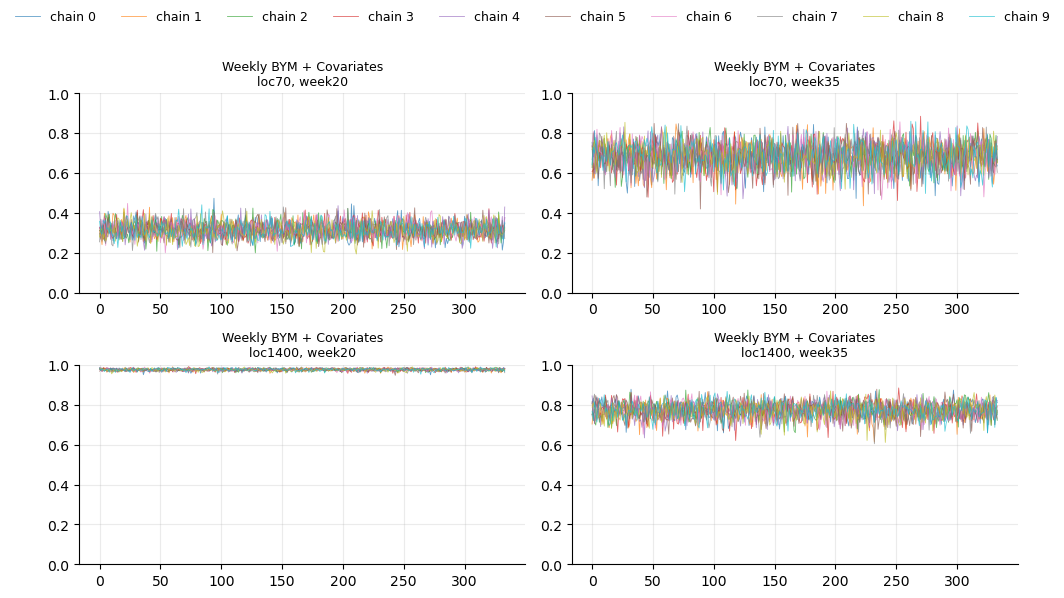

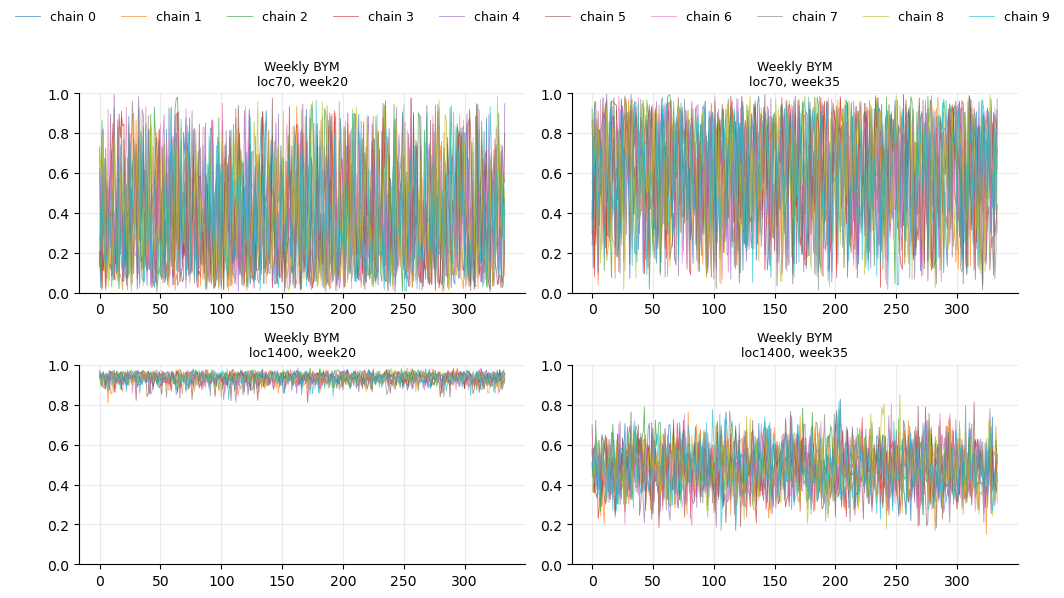

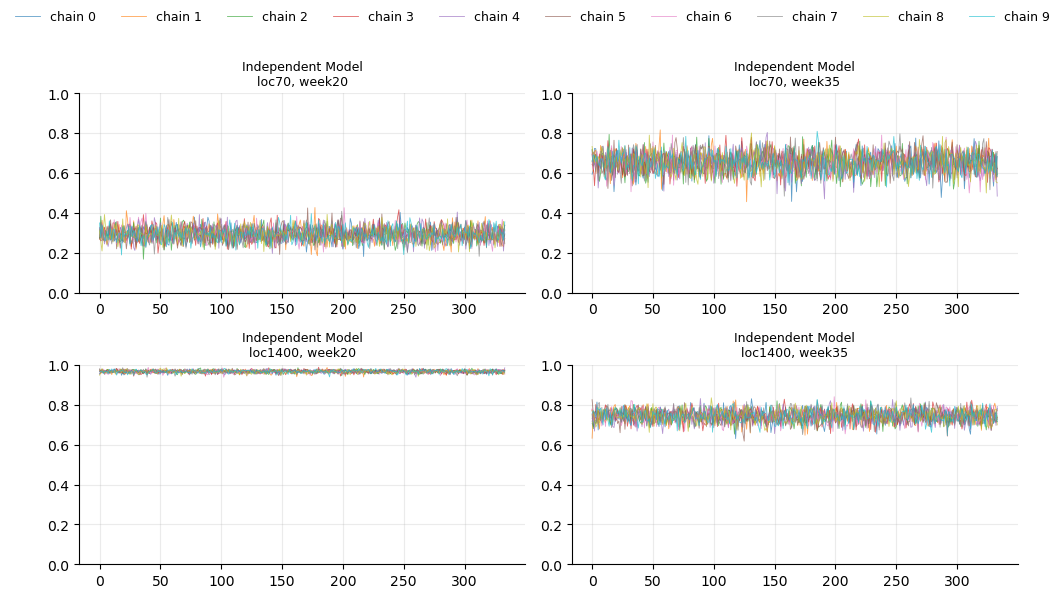

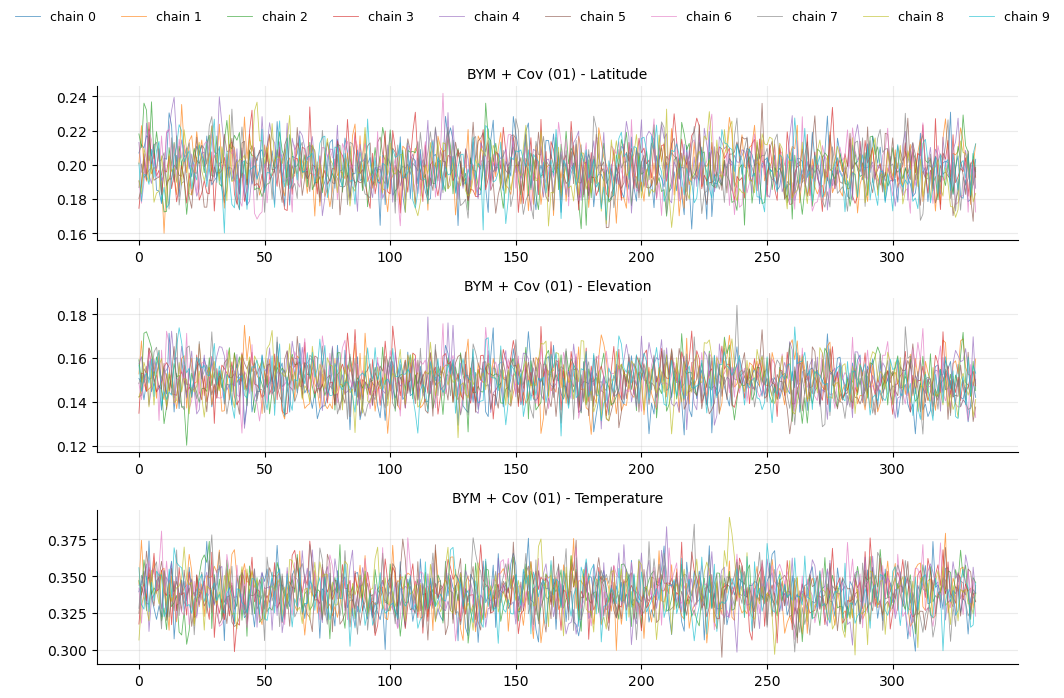

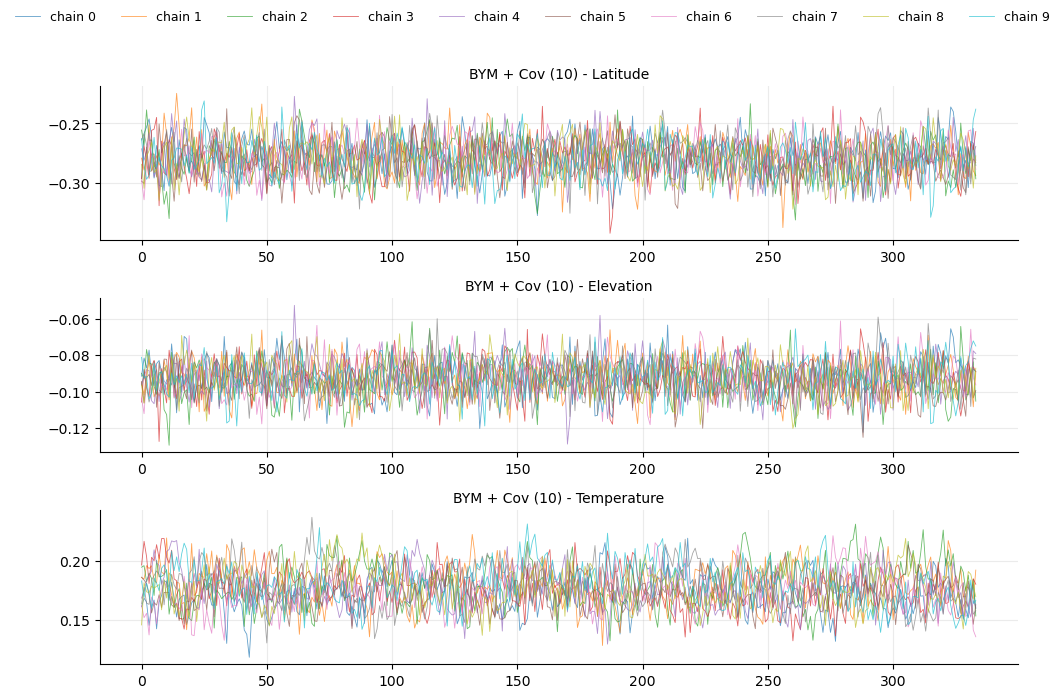

Done.


In [ ]:
# ================================================================
# FINAL TRACEPLOT VERSION (PAPER-READY, NO SAVE)
# ================================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import arviz as az
import pickle
import pyreadr
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

# ================================================================
# CONFIG
# ================================================================

BASE_DIR = Path(r"D:\77\Research\temp\snow")

period = 52
thin2 = 15

locations = [70, 1400]
weeks = [20, 35]
year = 20

times = [(year*52 + w - 1) for w in weeks]
chains = list(range(10))

# ================================================================
# LOAD DATA
# ================================================================

no_nbs = np.array([
57,170,236,269,343,685,946,947,989,
1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

def load_data():
    snow = pyreadr.read_r(BASE_DIR/"snow_cleaned_full.Rda")
    snow = list(snow.values())[0].reset_index(drop=True)
    snow = snow.drop(index=no_nbs).reset_index(drop=True)

    coords_full = snow.iloc[:, :2].to_numpy()
    y_full = snow.iloc[:, 2:].to_numpy()

    return coords_full, y_full

coords_full, y_full = load_data()

# adjacency
gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_full[:,0], coords_full[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6

W_full = (squareform(pdist(xy)) <= 0.22).astype(int)
np.fill_diagonal(W_full, 0)

n_comp, labels = connected_components(csr_matrix(W_full), directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_full[keep]
y = y_full[keep]

S, TT = y.shape

# ================================================================
# COVARIATES
# ================================================================

lat = (coords[:,1] - coords[:,1].mean()) / coords[:,1].std()

elev_raw = pd.read_csv(BASE_DIR/"curr_elev.csv").iloc[:,3].to_numpy()
elev = elev_raw[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR/"snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)

temp_full = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp_full = temp_full[keep]
temp_scaled = (temp_full - temp_full.mean()) / temp_full.std()

t_full = np.arange(1, TT+1)
t_scaled_full = (t_full - t_full.mean()) / t_full.std()

# ================================================================
# LOAD CHAINS
# ================================================================

def load_bym(prefix, use_cov=False):

    eta_list, tau_list = [], []

    for c in chains:

        fname = f"{prefix}_chain{c}+cov.pkl" if use_cov else f"{prefix}_chain{c}.pkl"

        with open(BASE_DIR / fname, "rb") as f:
            d = pickle.load(f)

        eta_list.append(d["eta"][:, ::thin2])
        tau_list.append(d["tau"][:, ::thin2])

    return eta_list, tau_list


def load_ind(prefix):

    eta_list = []

    for c in chains:
        d = np.load(BASE_DIR / f"{prefix}_chain{c}.npz")
        key = d.files[0]
        eta_list.append(d[key][:, ::thin2])

    return eta_list

# ================================================================
# POSTERIOR
# ================================================================

def compute_p_bym(eta_list, tau_list):

    K_total = 8
    S = (eta_list[0].shape[0] - 3)//K_total

    results = {}

    for s in locations:
        for t in times:

            w = t % 52
            t_scaled = t_scaled_full[t]

            cov4 = np.array([
                1,
                np.cos(2*np.pi*(t+1)/period),
                np.sin(2*np.pi*(t+1)/period),
                t_scaled
            ])

            chains_out = []

            for c in range(len(eta_list)):

                eta = eta_list[c]
                tau = tau_list[c]

                phi = np.zeros(eta.shape[1])

                for k in range(8):
                    phi += eta[k*S+s,:]*tau[k*52+w,:]*cov4[k//2]

                gamma = eta[8*S:8*S+3,:]

                phi += gamma[0]*t_scaled*lat[s]
                phi += gamma[1]*t_scaled*elev[s]
                phi += gamma[2]*t_scaled*temp_scaled[s,t]

                p = 1/(1+np.exp(-phi))
                p_final = p if y[s,t]==0 else 1-p

                chains_out.append(p_final)

            results[(s,t)] = chains_out

    return results


def compute_p_ind(eta_list):

    K = 4
    S = eta_list[0].shape[0] // K

    results = {}

    for s in locations:
        for t in times:

            t_scaled = t_scaled_full[t]

            cov4 = np.array([
                1,
                np.cos(2*np.pi*(t+1)/period),
                np.sin(2*np.pi*(t+1)/period),
                t_scaled
            ])

            chains_out = []

            for c in range(len(eta_list)):

                eta = eta_list[c]
                phi = np.zeros(eta.shape[1])

                for k in range(K):
                    phi += eta[k*S+s,:]*cov4[k]

                p = 1/(1+np.exp(-phi))
                p_final = p if y[s,t]==0 else 1-p

                chains_out.append(p_final)

            results[(s,t)] = chains_out

    return results

# ================================================================
# PLOT (FINAL)
# ================================================================

def plot_model_subplots(results, model_name):

    fig, axs = plt.subplots(len(locations), len(times), figsize=(10,6))
    axs = np.atleast_2d(axs)

    for i, s in enumerate(locations):
        for j, t in enumerate(times):

            chains = results[(s,t)]
            pooled = np.concatenate(chains)

            ax = axs[i,j]
            window = 200
            smooth = pd.Series(pooled).rolling(window, center=True).mean()

            # ---------- credible band ----------
            lower = pd.Series(pooled).rolling(window, center=True).quantile(0.1)
            upper = pd.Series(pooled).rolling(window, center=True).quantile(0.9)

            # ---------- plot ----------
            ax.plot(smooth, lw=1.2)
            ax.fill_between(
                np.arange(len(pooled)),
                lower,
                upper,
                alpha=0.25
            )

            ax.set_title(f"{model_name}\nloc{s}, week{t%52+1}", fontsize=9)

            ax.set_ylim(0,1)

            # clean
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(alpha=0.25)

            ax.set_xlabel("")
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()
# ================================================================
# GAMMA TRACE
# ================================================================

def plot_gamma_subplots(eta_list, model_name):

    K_total = 8
    S = (eta_list[0].shape[0] - 3) // K_total

    cov_names = ["Latitude", "Elevation", "Temperature"]

    fig, axs = plt.subplots(3, 1, figsize=(10,7))

    colors = plt.cm.tab10.colors

    for k in range(3):

        chains = []
        for c in range(len(eta_list)):
            chains.append(eta_list[c][8*S + k, :])

        ax = axs[k]

        for c, chain in enumerate(chains):
            ax.plot(
                chain,
                lw=0.6,
                alpha=0.7,
                color=colors[c % 10],
                label=f"chain {c}" if k==0 else None
            )

        ax.set_title(f"{model_name} - {cov_names[k]}", fontsize=10)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.25)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper center",
        ncol=len(chains),
        frameon=False,
        fontsize=9
    )

    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()

# ================================================================
# RUN
# ================================================================

print("Loading chains...")

eta10_cov, tau10_cov = load_bym("bym10", True)
eta10, tau10 = load_bym("bym10", False)
eta_ind10 = load_ind("ind10")

print("Computing posterior...")

res_cov = compute_p_bym(eta10_cov, tau10_cov)
res_bym = compute_p_bym(eta10, tau10)
res_ind = compute_p_ind(eta_ind10)

print("Plotting...")

plot_model_subplots(res_cov, "Weekly BYM + Covariates")
plot_model_subplots(res_bym, "Weekly BYM")
plot_model_subplots(res_ind, "Independent Model")

eta01_cov, _ = load_bym("bym01", True)

plot_gamma_subplots(eta01_cov, "BYM + Cov (01)")
plot_gamma_subplots(eta10_cov, "BYM + Cov (10)")

print("Done.")

In [3]:
from pathlib import Path
import numpy as np

BASE_DIR = Path(r"D:\77\Research\temp\snow")

def compute_trend(npz_file, out_file):
    
    data = np.load(BASE_DIR / npz_file)
    
    ini   = data["weekly_ini"]
    final = data["weekly_final"]
    
    ini_sum   = np.sum(ini[:,:,:,1], axis=2)
    final_sum = np.sum(final[:,:,:,1], axis=2)
    
    dpd = (final_sum - ini_sum) / 51
    
    mean  = np.quantile(dpd, 0.5, axis=0)
    sd    = dpd.std(axis=0)
    lower = np.quantile(dpd, 0.025, axis=0)
    upper = np.quantile(dpd, 0.975, axis=0)
    
    np.savez(BASE_DIR / out_file,
             mean=mean,
             sd=sd,
             lower=lower,
             upper=upper)

compute_trend("trend_ind.npz", "trend_ind_summary.npz")
compute_trend("trend_bym_weekly.npz", "trend_bym_summary.npz")
compute_trend("trend_weekly_bym+cov.npz", "trend_bymp_summary.npz")

In [1]:
import numpy as np
import pickle
from pathlib import Path

BASE_DIR = Path(r"D:\77\Research\temp\snow")

thin = 15
n_chains = 10

gamma01_list = []
gamma10_list = []

for c in range(n_chains):

    with open(BASE_DIR/f"bym01_chain{c}+cov.pkl","rb") as f:
        d = pickle.load(f)
    eta01 = d["eta"][:, ::thin]

    with open(BASE_DIR/f"bym10_chain{c}+cov.pkl","rb") as f:
        d = pickle.load(f)
    eta10 = d["eta"][:, ::thin]

    # infer S
    eta_dim = eta01.shape[0]
    S = (eta_dim - 3) // 8

    gamma01_list.append(eta01[8*S:, :])  # (3, M)
    gamma10_list.append(eta10[8*S:, :])

# concat chains
gamma01 = np.concatenate(gamma01_list, axis=1)
gamma10 = np.concatenate(gamma10_list, axis=1)

# --------------------------------------------------
# summary function
# --------------------------------------------------
def summarize(x):
    return {
        "mean":   np.mean(x),
        "median": np.median(x),
        "lower":  np.quantile(x, 0.025),
        "upper":  np.quantile(x, 0.975)
    }

# names
names = [
    r"$\gamma_1$ (lat)",
    r"$\gamma_2$ (elev)",
    r"$\gamma_3$ (temp)",
    r"$\tilde{\gamma}_1$ (lat)",
    r"$\tilde{\gamma}_2$ (elev)",
    r"$\tilde{\gamma}_3$ (temp)"
]

# collect results
rows = []

for i in range(3):
    s = summarize(gamma01[i])
    rows.append((names[i], s))

for i in range(3):
    s = summarize(gamma10[i])
    rows.append((names[i+3], s))

# --------------------------------------------------
# print LaTeX
# --------------------------------------------------
print(r"\begin{table}[htbp]")
print(r"\centering")
print(r"\begin{tabular}{lcccc}")
print(r"\hline")
print(r"Parameter & Mean & Median & 2.5\% & 97.5\% \\")
print(r"\hline")

for name, s in rows:
    print(f"{name} & {s['mean']:.4f} & {s['median']:.4f} & {s['lower']:.4f} & {s['upper']:.4f} \\\\")

print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{Posterior summaries of covariate effects.}")
print(r"\end{table}")

\begin{table}[htbp]
\centering
\begin{tabular}{lcccc}
\hline
Parameter & Mean & Median & 2.5\% & 97.5\% \\
\hline
$\gamma_1$ (lat) & 0.1979 & 0.1978 & 0.1736 & 0.2232 \\
$\gamma_2$ (elev) & 0.1498 & 0.1498 & 0.1333 & 0.1669 \\
$\gamma_3$ (temp) & 0.3383 & 0.3385 & 0.3122 & 0.3655 \\
$\tilde{\gamma}_1$ (lat) & -0.2792 & -0.2788 & -0.3107 & -0.2478 \\
$\tilde{\gamma}_2$ (elev) & -0.0926 & -0.0924 & -0.1127 & -0.0731 \\
$\tilde{\gamma}_3$ (temp) & 0.1771 & 0.1769 & 0.1453 & 0.2109 \\
\hline
\end{tabular}
\caption{Posterior summaries of covariate effects.}
\end{table}
